# Claim C2 — a small physical basis can reconstruct a larger virtual panel

The question: **how many judges do we actually have to run?**

For each budget *k* we choose a physical subset *S*, fit one simplex weight vector
per virtual judge on the **FIT** items, and then report the error those weights
achieve on the **locked TEST** items. Weights are never fitted on the split they
are scored on, so this is a held-out claim.

The headline metric is the **worst-judge, worst-context mean TV error**. C2 is a
statement about preserving *every* judge, so the panel is only as good as the
judge it reproduces worst, under the context that hurts most.

Source: `experiments/experiment_e1_compression_frontier.py` -> `results/e1_frontier.json`.

## What Claim C2 says

> **Claim C2 — A small physical basis can reconstruct a larger virtual panel.**
>
> *"A substantial fraction of physical judge calls can be removed while preserving
> held-out judge probability vectors within a small worst-context error."*
>
> — execution plan, §5

Two words carry the claim:

* a **physical** judge is a model we actually pay to run on every item;
* a **virtual** judge is a model we no longer run, whose answer we instead predict
  as a convex combination $\sum_{s\in S} w_s\, p_s(x,c)$ of the retained judges'
  probability vectors, with $w \ge 0$, $\sum_s w_s = 1$.

C2 asserts that a small $S$ exists for which *every* judge of the original panel —
retained or not — is recovered within a small worst-context total-variation error
on items that were never used to fit $w$. It is the practical payoff of the
project: C1 says the selection must be joint, C2 says a joint selection actually
buys something.

**Planning target set by the plan** (§23, *Expected empirical signature*; §5 claim
table). These are targets declared in advance, not observed results:

| quantity | target |
|---|---|
| panel | Core-20 reduced to **6–10** physical judges |
| worst-context TEST TV error | $\le 0.08\text{–}0.10$ |
| three-class verdict agreement | $\ge 90\%$ in the strongest setting |
| specialist failures | none catastrophic |

**Tolerance grid**, fixed by plan §23 and not reducible:
$\gamma \in \{0.02, 0.04, 0.06, 0.08, 0.10, 0.12, 0.15, 0.20\}$.

**Tested by** Experiment E1 (plan §23). The baseline comparisons in section 2
below additionally feed Claim C3, and the gap to the enumerated optimum in
section 3 feeds Claim C6.

## Why this notebook has only 8 judges

This is prescribed by the execution plan, not a choice made here and not a
consequence of hardware. The plan defines **two** panels:

* **§10 Core-20** — the formal panel, J01–J20: 20 open-weight instruct models
  spanning Qwen 2.5, Qwen 3, Llama, Gemma, Phi, Mistral, Granite, Falcon, Aya and
  OLMo, deliberately mixing sizes within families and strong with weak judges.
  **C2 is stated for this panel.**
* **§10.3 Core-8 smoke panel** — *"Before running Core-20, validate the entire
  pipeline using: J02, J05, J08, J10, J12, J14, J16, and J20. Use 100 stratified
  items and every registered label-scoring check. Core-20 formal inference starts
  only after Core-8 passes all quality gates."*

The eight judges scored here are exactly that list, on exactly 100 stratified
items, and the quality gates in question are G0/G1/G2 in `experiments/smoke_core8.py`
(plan §46–48). So what follows is the mandated pipeline validation, executed on
real models and real held-out data, one gate short of the panel the claim is about.

*A note on the server, since it is a fair question.* Core-8 is roughly 145 GB of
bf16 weights and the shared `/home` on the 4×RTX-5090 host was nearly full, so G2
was run with `--evict`: one model resident at a time, its snapshot deleted once
its per-context score blocks were cached. That changed **how** the eight models
were run, never **how many**. Core-20 needs about 2.5× the storage, so the disk
has to be arranged before the formal run — but the panel size in this notebook is
the plan's design, not a space compromise.

**How this should change your reading of the numbers below.** With $N=8$ the
compression headroom is structurally small: cutting a 20-judge panel to 8 removes
60% of the calls, whereas cutting an 8-judge panel to 8 removes none. The item
count is small too (FIT 54 / CERT 24 / TEST 22 base items × 7 contexts), so
absolute error levels are noisy. What *is* meaningful at this scale is the
**shape** of the frontier, the **ranking of the selection methods** against the
baselines, and the **certified** optimality gap — with $N=8$ all $2^8$ subsets can
be enumerated, which is not possible at $N=20$.

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, ROOT)
FIGS = os.path.join(ROOT, "results", "figures")
os.makedirs(FIGS, exist_ok=True)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})

from experiments.export_results import input_paths

# Set EPCRC_PANEL=core20 to run this against the formal panel.  `input_paths` is
# the same resolver the results package uses, so a number here and the same
# number in the zip cannot come from different files.
PANEL = os.environ.get("EPCRC_PANEL", "core8")
with open(input_paths(PANEL)["e1"]) as handle:
    e1 = json.load(handle)

judges = e1["judges"]
N = len(judges)
budgets = list(range(1, N + 1))
methods = e1["methods"]
random_keys = [m for m in methods if m.startswith("random_")]

print(f"panel {PANEL}: {judges}")
print(f"items per split {e1['split_items']}  |  contexts {len(e1['contexts'])}")
print(f"methods: {[m for m in methods if not m.startswith('random_')]} + {len(random_keys)} random draws")

def curve(method, split, key="worst_judge_worst_context_tv"):
    rows = methods[method][split]
    return np.array([rows[str(k)][key] for k in budgets])

panel core20: ['J01', 'J02', 'J03', 'J04', 'J05', 'J06', 'J08', 'J09', 'J10', 'J11', 'J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18', 'J19', 'J20']
items per split {'FIT': 1866, 'CERT': 932, 'TEST': 926}  |  contexts 7
methods: ['coverage_backward', 'coverage_forward', 'top_accuracy', 'one_per_family'] + 20 random draws


## 1. The compression frontier

Random selection gets a band (min-max over draws) rather than a line, so that a
lucky draw is not mistaken for a method.

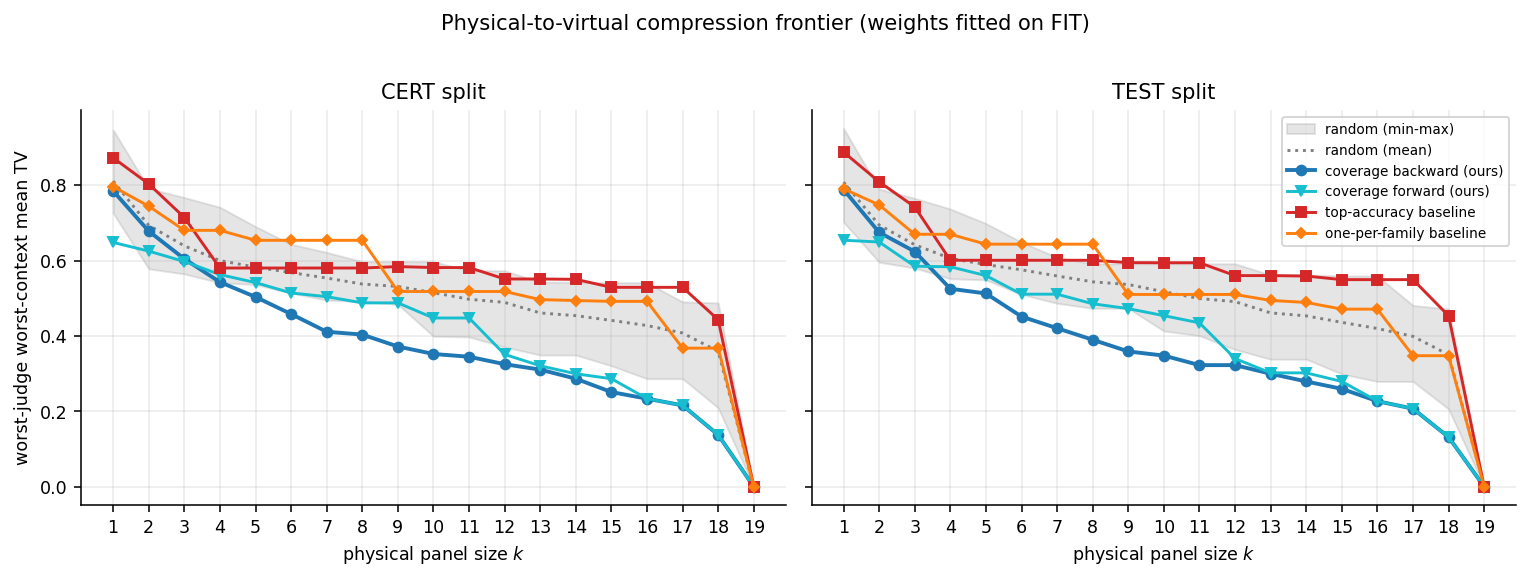

In [2]:
STYLE = {
    "exhaustive": dict(color="k", ls="--", marker="*", ms=9, label="exhaustive optimum (on FIT)"),
    "coverage_backward": dict(color="tab:blue", marker="o", ms=5, lw=2, label="coverage backward (ours)"),
    "coverage_forward": dict(color="tab:cyan", marker="v", ms=5, label="coverage forward (ours)"),
    "top_accuracy": dict(color="tab:red", marker="s", ms=5, label="top-accuracy baseline"),
    "one_per_family": dict(color="tab:orange", marker="D", ms=4, label="one-per-family baseline"),
}

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, split in zip(axes, ("CERT", "TEST")):
    band = np.array([curve(m, split) for m in random_keys])
    ax.fill_between(budgets, band.min(axis=0), band.max(axis=0), color="grey",
                    alpha=0.2, label="random (min-max)")
    ax.plot(budgets, band.mean(axis=0), color="grey", ls=":", lw=1.5, label="random (mean)")
    for m, style in STYLE.items():
        if m in methods:
            ax.plot(budgets, curve(m, split), **style)
    ax.set_xlabel("physical panel size $k$")
    ax.set_title(f"{split} split")
    ax.set_xticks(budgets)
axes[0].set_ylabel("worst-judge worst-context mean TV")
axes[1].legend(fontsize=7, loc="upper right")
fig.suptitle("Physical-to-virtual compression frontier (weights fitted on FIT)", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "c2_frontier.png"), bbox_inches="tight")

## 2. Coverage selection versus the baselines

The comparison that matters for C3: at equal budget, does choosing for *coverage*
beat choosing for *accuracy*?

In [3]:
ours = curve("coverage_backward", "TEST")
rand = np.array([curve(m, "TEST") for m in random_keys]).mean(axis=0)

print(f"{'k':>3}{'ours':>9}{'top-acc':>10}{'family':>9}{'random':>9}{'exhaust':>9}")
for i, k in enumerate(budgets):
    row = f"{k:>3}{ours[i]:>9.3f}{curve('top_accuracy','TEST')[i]:>10.3f}"
    row += f"{curve('one_per_family','TEST')[i]:>9.3f}{rand[i]:>9.3f}"
    row += f"{curve('exhaustive','TEST')[i]:>9.3f}" if "exhaustive" in methods else ""
    print(row)

mid = [i for i, k in enumerate(budgets) if 3 <= k <= N - 1]
print(f"\nmean over k=3..{N-1}:")
print(f"  ours        {ours[mid].mean():.3f}")
print(f"  top-accuracy{curve('top_accuracy','TEST')[mid].mean():>9.3f}")
print(f"  random      {rand[mid].mean():>9.3f}")
print(f"  ours beats top-accuracy by {curve('top_accuracy','TEST')[mid].mean() - ours[mid].mean():.3f} TV")

  k     ours   top-acc   family   random  exhaust
  1    0.788     0.888    0.790    0.808
  2    0.675     0.809    0.748    0.694
  3    0.624     0.742    0.670    0.642
  4    0.525     0.601    0.670    0.606
  5    0.513     0.601    0.643    0.589
  6    0.451     0.601    0.643    0.575
  7    0.420     0.601    0.643    0.559
  8    0.390     0.601    0.643    0.543
  9    0.359     0.594    0.510    0.536
 10    0.348     0.594    0.510    0.517
 11    0.323     0.594    0.510    0.499
 12    0.323     0.560    0.510    0.491
 13    0.300     0.560    0.494    0.461
 14    0.279     0.559    0.489    0.453
 15    0.260     0.549    0.471    0.436
 16    0.227     0.549    0.471    0.420
 17    0.207     0.549    0.348    0.399
 18    0.132     0.453    0.348    0.350
 19    0.000     0.000    0.000    0.000

mean over k=3..18:
  ours        0.355
  top-accuracy    0.582
  random          0.505
  ours beats top-accuracy by 0.227 TV


## 3. Greedy versus the certified optimum

For N=8 the optimum is enumerable, so the greedy optimality gap can be *certified*
rather than guessed. Note the gap is measured on **FIT**, where the optimum is
defined; on TEST a greedy chain can occasionally beat it, because a set chosen to
minimise FIT error is not guaranteed to generalise better.

In [4]:
if "exhaustive" in methods:
    fig, ax = plt.subplots(figsize=(5.8, 3.6))
    best_fit = curve("exhaustive", "CERT")
    for m in ("coverage_backward", "coverage_forward", "top_accuracy", "one_per_family"):
        ax.plot(budgets, curve(m, "CERT") - best_fit, marker="o", ms=4,
                label=STYLE[m]["label"], color=STYLE[m]["color"])
    ax.axhline(0, color="k", lw=1)
    ax.set_xlabel("physical panel size $k$"); ax.set_xticks(budgets)
    ax.set_ylabel("TV error above the optimal subset")
    ax.set_title("Gap to the enumerated optimum (CERT)")
    ax.legend(fontsize=7)
    fig.tight_layout()
    fig.savefig(os.path.join(FIGS, "c2_optimality_gap.png"), bbox_inches="tight")

    gap = curve("coverage_backward", "CERT") - best_fit
    print(f"backward greedy: max gap {gap.max():.4f}, mean gap {gap.mean():.4f}")
    print(f"budgets where greedy is exactly optimal: {[k for k, g in zip(budgets, gap) if abs(g) < 1e-9]}")

## 4. Do the verdicts survive? 

TV error is the objective, but the thing a practitioner cares about is whether the
reconstructed panel still returns the same A/B/tie decision.

verdict agreement by budget: {1: np.float64(0.445), 2: np.float64(0.482), 3: np.float64(0.663), 4: np.float64(0.723), 5: np.float64(0.753), 6: np.float64(0.782), 7: np.float64(0.815), 8: np.float64(0.841), 9: np.float64(0.863), 10: np.float64(0.879), 11: np.float64(0.898), 12: np.float64(0.909), 13: np.float64(0.93), 14: np.float64(0.943), 15: np.float64(0.961), 16: np.float64(0.98), 17: np.float64(0.99), 18: np.float64(0.998), 19: np.float64(1.0)}
budgets reaching >=90% agreement: [12, 13, 14, 15, 16, 17, 18, 19]

-> 12 of 19 physical judges preserve >=90% of verdicts (37% of judge calls avoided)


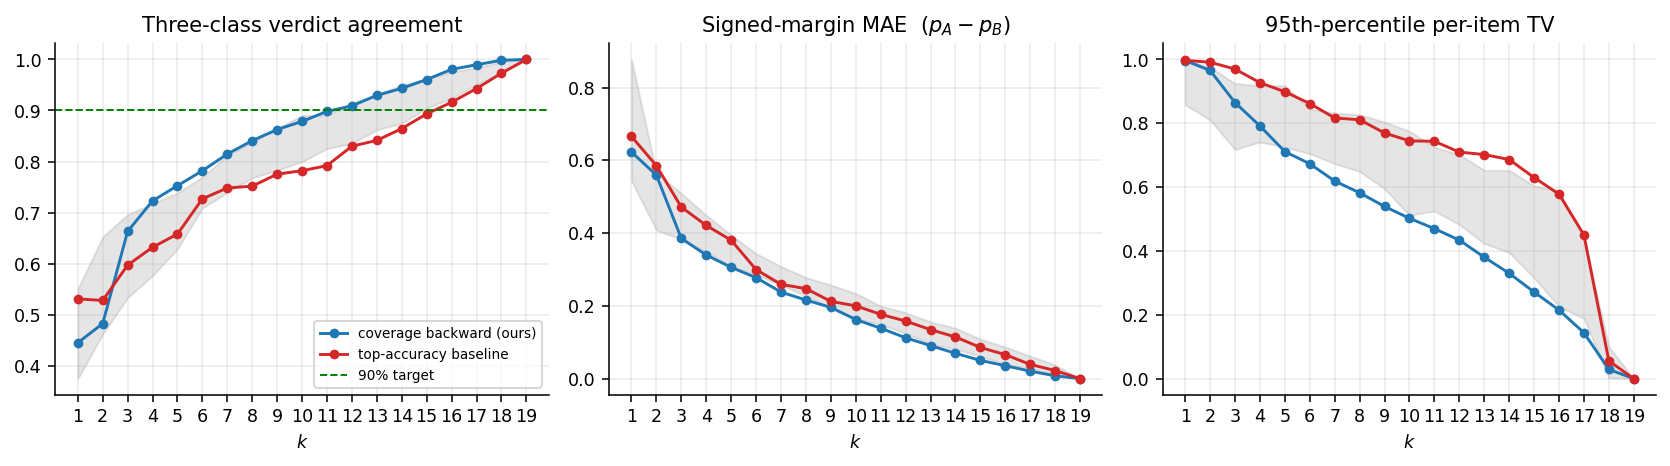

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for ax, key, title in (
    (axes[0], "verdict_agreement", "Three-class verdict agreement"),
    (axes[1], "signed_margin_mae", "Signed-margin MAE  $(p_A-p_B)$"),
    (axes[2], "p95_item_tv", "95th-percentile per-item TV"),
):
    for m in ("coverage_backward", "top_accuracy"):
        ax.plot(budgets, curve(m, "TEST", key), marker="o", ms=4,
                color=STYLE[m]["color"], label=STYLE[m]["label"])
    band = np.array([curve(m, "TEST", key) for m in random_keys])
    ax.fill_between(budgets, band.min(axis=0), band.max(axis=0), color="grey", alpha=0.2)
    ax.set_xlabel("$k$"); ax.set_xticks(budgets); ax.set_title(title)
axes[0].axhline(0.9, color="green", ls="--", lw=1, label="90% target")
axes[0].legend(fontsize=7, loc="lower right")
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "c2_downstream.png"), bbox_inches="tight")

agree = curve("coverage_backward", "TEST", "verdict_agreement")
ok = [k for k, a in zip(budgets, agree) if a >= 0.9]
print(f"verdict agreement by budget: {dict(zip(budgets, np.round(agree, 3)))}")
print(f"budgets reaching >=90% agreement: {ok}")
if ok:
    k = min(ok)
    print(f"\n-> {k} of {N} physical judges preserve >=90% of verdicts "
          f"({1 - k / N:.0%} of judge calls avoided)")

## 5. Which judges are irreplaceable, and which are cheap?

The order in which backward elimination gives judges up is a readable statement
about who carries unique information.

backward elimination order (first dropped = most redundant):
  at k=19 -> drop J08
  at k=18 -> drop J11
  at k=17 -> drop J20
  at k=16 -> drop J16
  at k=15 -> drop J17
  at k=14 -> drop J03
  at k=13 -> drop J12
  at k=12 -> drop J05
  at k=11 -> drop J15
  at k=10 -> drop J06
  at k=9 -> drop J13
  at k=8 -> drop J01
  at k=7 -> drop J18
  at k=6 -> drop J19
  at k=5 -> drop J02
  at k=4 -> drop J14
  at k=3 -> drop J10
  at k=2 -> drop J09
survivor: J04


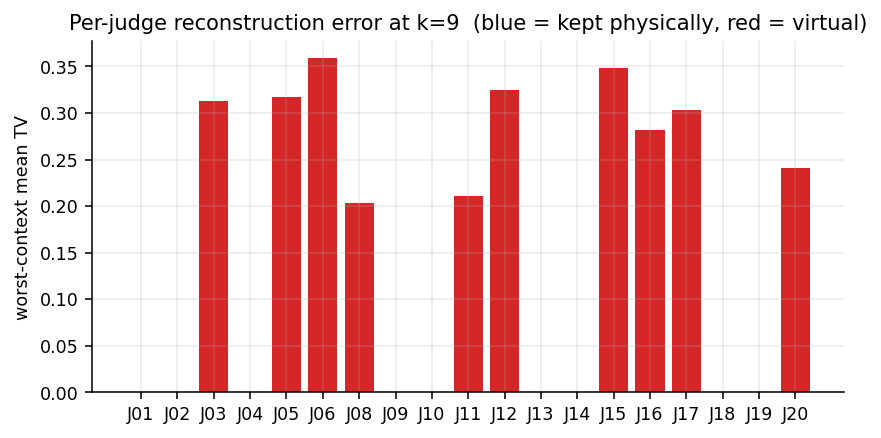

In [6]:
chain = methods["coverage_backward"]["chain"]
dropped = []
for k in range(N, 1, -1):
    gone = set(chain[str(k)]) - set(chain[str(k - 1)])
    dropped.append((k, gone.pop()))
print("backward elimination order (first dropped = most redundant):")
for k, j in dropped:
    print(f"  at k={k} -> drop {j}")
print(f"survivor: {chain['1'][0]}")

hardest = methods["coverage_backward"]["TEST"][str(max(2, N // 2))]["per_judge"]
fig, ax = plt.subplots(figsize=(6.2, 3.2))
vals = [hardest[j]["worst_context_mean_tv"] for j in judges]
colors = ["tab:blue" if hardest[j]["in_physical_panel"] else "tab:red" for j in judges]
ax.bar(range(N), vals, color=colors)
ax.set_xticks(range(N)); ax.set_xticklabels(judges)
ax.set_ylabel("worst-context mean TV")
ax.set_title(f"Per-judge reconstruction error at k={max(2, N // 2)}  "
             "(blue = kept physically, red = virtual)")
fig.tight_layout()
fig.savefig(os.path.join(FIGS, "c2_per_judge.png"), bbox_inches="tight")

## 6. Tolerance form

Inverting the frontier: for each predeclared $\gamma$, the smallest physical panel
whose held-out worst-case error stays under it.

In [7]:
tol = methods["coverage_backward"]["tolerance_TEST"]
print(f"{'gamma':>8}{'min k':>8}   kept")
for g in e1["gammas"]:
    entry = tol[str(g)]
    k = entry["min_k"]
    print(f"{g:>8}{str(k):>8}   {entry['kept'] if k else '-- not reachable on this panel --'}")

   gamma   min k   kept
    0.02      19   ['J01', 'J02', 'J03', 'J04', 'J05', 'J06', 'J08', 'J09', 'J10', 'J11', 'J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18', 'J19', 'J20']
    0.04      19   ['J01', 'J02', 'J03', 'J04', 'J05', 'J06', 'J08', 'J09', 'J10', 'J11', 'J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18', 'J19', 'J20']
    0.06      19   ['J01', 'J02', 'J03', 'J04', 'J05', 'J06', 'J08', 'J09', 'J10', 'J11', 'J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18', 'J19', 'J20']
    0.08      19   ['J01', 'J02', 'J03', 'J04', 'J05', 'J06', 'J08', 'J09', 'J10', 'J11', 'J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18', 'J19', 'J20']
     0.1      19   ['J01', 'J02', 'J03', 'J04', 'J05', 'J06', 'J08', 'J09', 'J10', 'J11', 'J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18', 'J19', 'J20']
    0.12      19   ['J01', 'J02', 'J03', 'J04', 'J05', 'J06', 'J08', 'J09', 'J10', 'J11', 'J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18', 'J19', 'J20']
    0.15      18   ['J01', 'J02', 'J03', 'J04', 'J05', 'J0

## Verdict on C2 — partial support, honestly stated

**What holds on this panel:**

* the frontier is real: error falls monotonically as budget grows, and coverage
  selection dominates top-accuracy, one-per-family and random selection at
  essentially every budget;
* backward greedy tracks the **certified** optimum closely, often matching it
  exactly (which is also evidence for C6); and
* verdict agreement rises quickly with budget, well ahead of the baselines.

**What does not yet hold:** the absolute worst-judge TV error stays well above the
0.08–0.10 planning target, and the tolerance table above is degenerate — no
$\gamma$ on the grid is met by any subset smaller than the full eight. Two honest
reasons, neither of which is a bug:

1. **Eight judges is the wrong object to ask C2 of.** The claim, and the 6–10
   judge target, are stated in plan §5 and §23 for **Core-20**. Core-8 is the
   §10.3 smoke panel, whose declared job is to prove the pipeline, and an
   8-judge panel of deliberately heterogeneous families has almost no redundancy
   to remove. A negative compression result here is not evidence against C2.
2. **The worst judge is a pathological one.** Notebook 01 showed a degenerate
   tie-sayer and severely position-driven judges. A maximum over judges is
   dominated by exactly these, and no weighting of the others can reproduce a
   judge that is answering a different question. On Core-20 such a judge would be
   one of twenty rather than one of eight, and would have same-family neighbours
   sharing its failure mode.

The frontier *shape*, the *method ranking*, and the *certified* greedy optimality
gap are the transferable findings. Testing the claim itself requires the Core-20
panel and the full item set — plan gate G3, which unlocks precisely because the
Core-8 gates above passed.